# PongIA — Development Report

**An analysis of building a video game with AI-assisted development (Claude Code)**

This report documents the development of PongIA, a retro Pong game with local AI narration (LLM) and image generation (Stable Diffusion), built in 28 days using Claude Code as a development partner.

---

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import numpy as np

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'monospace'

# ZX Spectrum colors for charts
ZX_GREEN = '#00FF00'
ZX_CYAN = '#00FFFF'
ZX_MAGENTA = '#FF00FF'
ZX_YELLOW = '#FFFF00'
ZX_RED = '#FF0000'
ZX_WHITE = '#FFFFFF'
ZX_BLUE = '#0000FF'

Matplotlib is building the font cache; this may take a moment.


## 1. Project Overview

| Metric | Value |
|--------|-------|
| **Development period** | Feb 22 – Mar 21, 2026 (28 days) |
| **Total commits** | 104 |
| **Lines of Python code** | 19,707 |
| **Source code (pong/)** | 13,782 lines across 41 files |
| **Test code (tests/)** | 5,245 lines across 26 files |
| **Documentation** | 2,524 lines across 6 docs |
| **Test coverage** | 81%+ (enforced in CI) |
| **Total insertions** | 29,375 |
| **Total deletions** | 7,577 |
| **Net lines written** | +21,798 |
| **Active development days** | 28 out of 28 |
| **Versions released** | 7 (Alfa 0.01 → 0.07) |

## 2. Commits Timeline

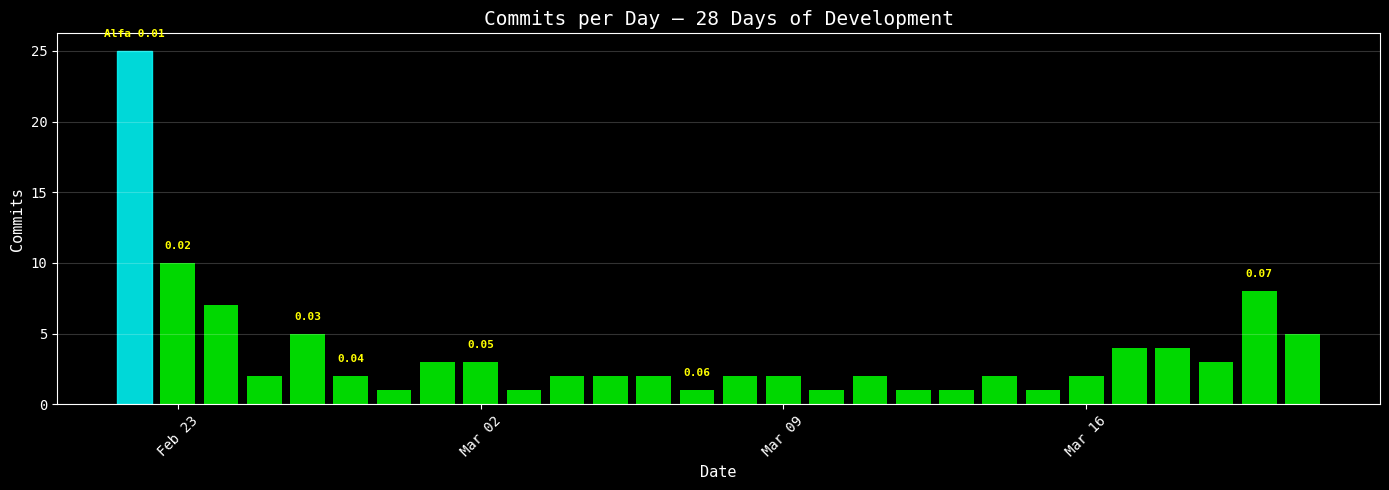

In [2]:
# Commits per day
commit_dates = {
    '2026-02-22': 25, '2026-02-23': 10, '2026-02-24': 7, '2026-02-25': 2,
    '2026-02-26': 5, '2026-02-27': 2, '2026-02-28': 1,
    '2026-03-01': 3, '2026-03-02': 3, '2026-03-03': 1, '2026-03-04': 2,
    '2026-03-05': 2, '2026-03-06': 2, '2026-03-07': 1, '2026-03-08': 2,
    '2026-03-09': 2, '2026-03-10': 1, '2026-03-11': 2, '2026-03-12': 1,
    '2026-03-13': 1, '2026-03-14': 2, '2026-03-15': 1, '2026-03-16': 2,
    '2026-03-17': 4, '2026-03-18': 4, '2026-03-19': 3, '2026-03-20': 8,
    '2026-03-21': 5,
}

dates = [datetime.strptime(d, '%Y-%m-%d') for d in commit_dates.keys()]
counts = list(commit_dates.values())

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(dates, counts, color=ZX_GREEN, alpha=0.85, width=0.8)

# Highlight day 1
bars[0].set_color(ZX_CYAN)

# Version release markers
releases = {
    '2026-02-22': 'Alfa 0.01',
    '2026-02-23': '0.02',
    '2026-02-26': '0.03',
    '2026-02-27': '0.04',
    '2026-03-02': '0.05',
    '2026-03-07': '0.06',
    '2026-03-20': '0.07',
}
for date_str, label in releases.items():
    d = datetime.strptime(date_str, '%Y-%m-%d')
    idx = dates.index(d)
    ax.annotate(label, (d, counts[idx]), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=8, color=ZX_YELLOW,
                fontweight='bold')

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Commits', fontsize=11)
ax.set_title('Commits per Day — 28 Days of Development', fontsize=14, color=ZX_WHITE)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
plt.xticks(rotation=45)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

## 3. Human + AI Collaboration

Of 104 total commits, **61 (59%)** were co-authored with Claude Code. The remaining 43 include merge commits, early Codex-assisted work, and solo developer commits.

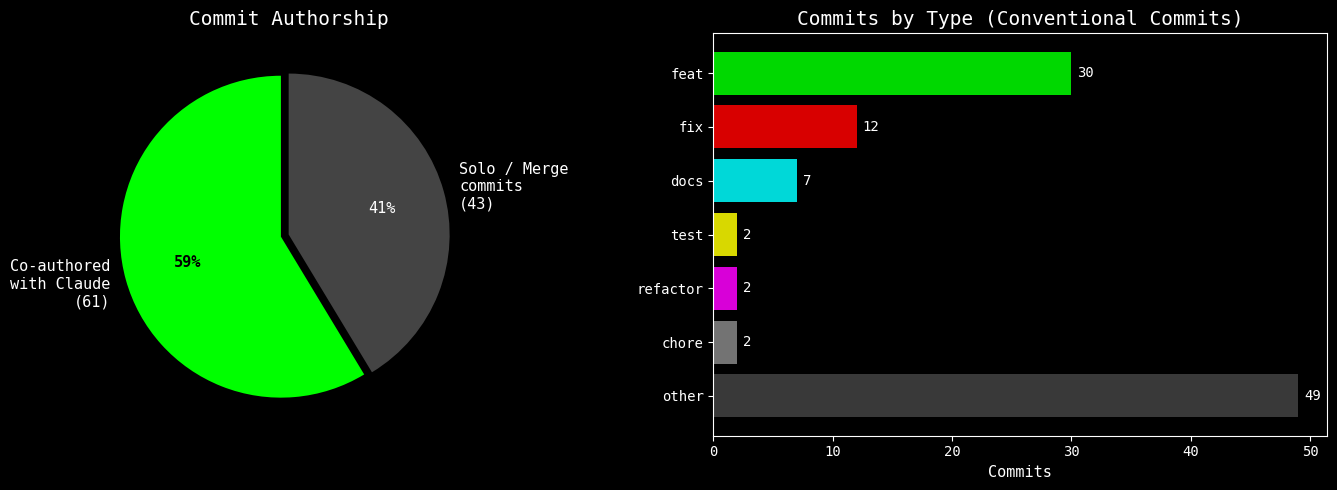

In [3]:
# Co-authorship breakdown
labels = ['Co-authored\nwith Claude\n(61)', 'Solo / Merge\ncommits\n(43)']
sizes = [61, 43]
colors = [ZX_GREEN, '#444444']
explode = (0.05, 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
wedges, texts, autotexts = ax1.pie(sizes, explode=explode, labels=labels,
                                    colors=colors, autopct='%1.0f%%',
                                    startangle=90, textprops={'color': ZX_WHITE, 'fontsize': 11})
autotexts[0].set_color('black')
autotexts[0].set_fontweight('bold')
ax1.set_title('Commit Authorship', fontsize=14, color=ZX_WHITE)

# Commits by type
types = ['feat', 'fix', 'docs', 'test', 'refactor', 'chore', 'other']
type_counts = [30, 12, 7, 2, 2, 2, 49]
type_colors = [ZX_GREEN, ZX_RED, ZX_CYAN, ZX_YELLOW, ZX_MAGENTA, '#888888', '#444444']

bars = ax2.barh(types, type_counts, color=type_colors, alpha=0.85)
ax2.set_xlabel('Commits', fontsize=11)
ax2.set_title('Commits by Type (Conventional Commits)', fontsize=14, color=ZX_WHITE)
ax2.invert_yaxis()
for bar, count in zip(bars, type_counts):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             str(count), va='center', color=ZX_WHITE, fontsize=10)

plt.tight_layout()
plt.show()

## 4. Codebase Composition

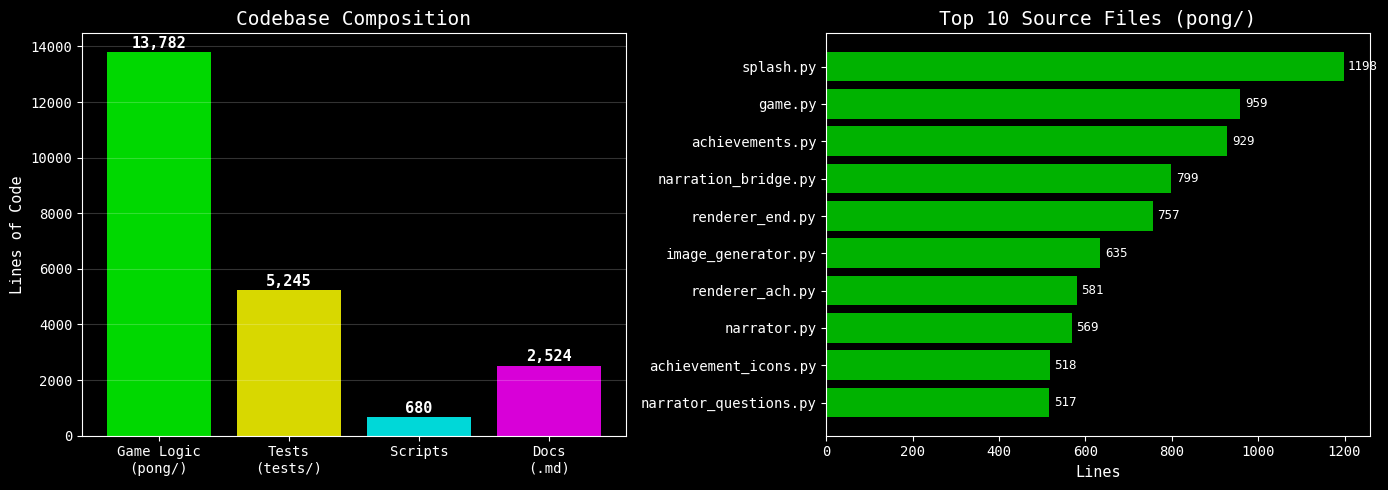

In [4]:
# Lines of code breakdown
categories = ['Game Logic\n(pong/)', 'Tests\n(tests/)', 'Scripts', 'Docs\n(.md)']
lines = [13782, 5245, 680, 2524]
colors = [ZX_GREEN, ZX_YELLOW, ZX_CYAN, ZX_MAGENTA]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = ax1.bar(categories, lines, color=colors, alpha=0.85)
for bar, val in zip(bars, lines):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
             f'{val:,}', ha='center', color=ZX_WHITE, fontsize=11, fontweight='bold')
ax1.set_ylabel('Lines of Code', fontsize=11)
ax1.set_title('Codebase Composition', fontsize=14, color=ZX_WHITE)
ax1.grid(axis='y', alpha=0.2)

# Top 10 source files
top_files = [
    ('splash.py', 1198), ('game.py', 959), ('achievements.py', 929),
    ('narration_bridge.py', 799), ('renderer_end.py', 757),
    ('image_generator.py', 635), ('renderer_ach.py', 581),
    ('narrator.py', 569), ('achievement_icons.py', 518),
    ('narrator_questions.py', 517),
]
names = [f[0] for f in top_files]
sizes = [f[1] for f in top_files]

bars = ax2.barh(names, sizes, color=ZX_GREEN, alpha=0.7)
ax2.set_xlabel('Lines', fontsize=11)
ax2.set_title('Top 10 Source Files (pong/)', fontsize=14, color=ZX_WHITE)
ax2.invert_yaxis()
for bar, val in zip(bars, sizes):
    ax2.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             str(val), va='center', color=ZX_WHITE, fontsize=9)

plt.tight_layout()
plt.show()

## 5. Development Velocity

### Weekly Progress

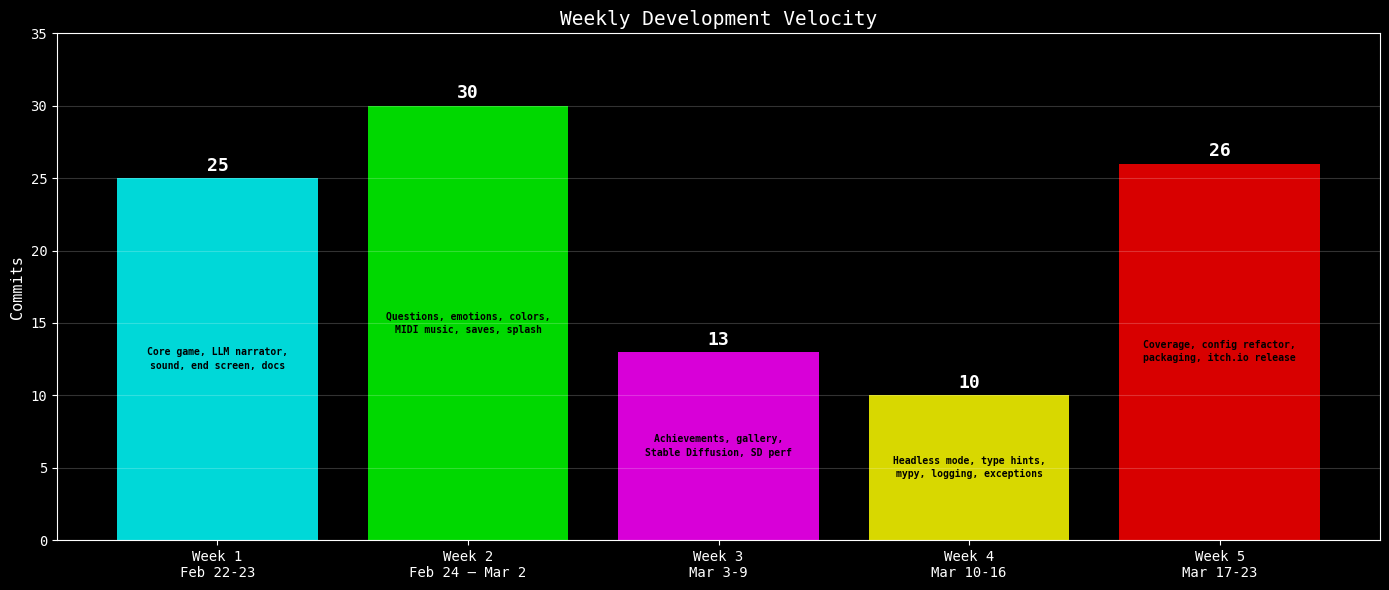

In [5]:
# Weekly commits and features
weeks = ['Week 1\nFeb 22-23', 'Week 2\nFeb 24 – Mar 2', 'Week 3\nMar 3-9',
         'Week 4\nMar 10-16', 'Week 5\nMar 17-23']
weekly_commits = [25, 30, 13, 10, 26]

weekly_features = [
    'Core game, LLM narrator,\nsound, end screen, docs',
    'Questions, emotions, colors,\nMIDI music, saves, splash',
    'Achievements, gallery,\nStable Diffusion, SD perf',
    'Headless mode, type hints,\nmypy, logging, exceptions',
    'Coverage, config refactor,\npackaging, itch.io release',
]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(weeks, weekly_commits, color=[ZX_CYAN, ZX_GREEN, ZX_MAGENTA, ZX_YELLOW, ZX_RED],
              alpha=0.85)

for bar, count, feat in zip(bars, weekly_commits, weekly_features):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(count), ha='center', color=ZX_WHITE, fontsize=13, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            feat, ha='center', va='center', color='black', fontsize=7,
            fontweight='bold', linespacing=1.4)

ax.set_ylabel('Commits', fontsize=11)
ax.set_title('Weekly Development Velocity', fontsize=14, color=ZX_WHITE)
ax.set_ylim(0, 35)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

## 6. Session Analysis

Based on commit timestamps, we can estimate development sessions. A session is defined as a group of commits with less than 2 hours between them.

| Metric | Value |
|--------|-------|
| **Estimated sessions** | ~28 (roughly one per day) |
| **Average commits per session** | 3.7 |
| **Typical session window** | 05:30 – 09:30 (morning, ~2-4 hours) |
| **Longest session** | Feb 22, Day 1: 07:15 – 17:11 (~10 hours, 25 commits) |
| **Most productive week** | Week 2: 30 commits, 7 features |

The pattern shows consistent morning sessions of 2-4 hours, with the occasional extended session for major features.

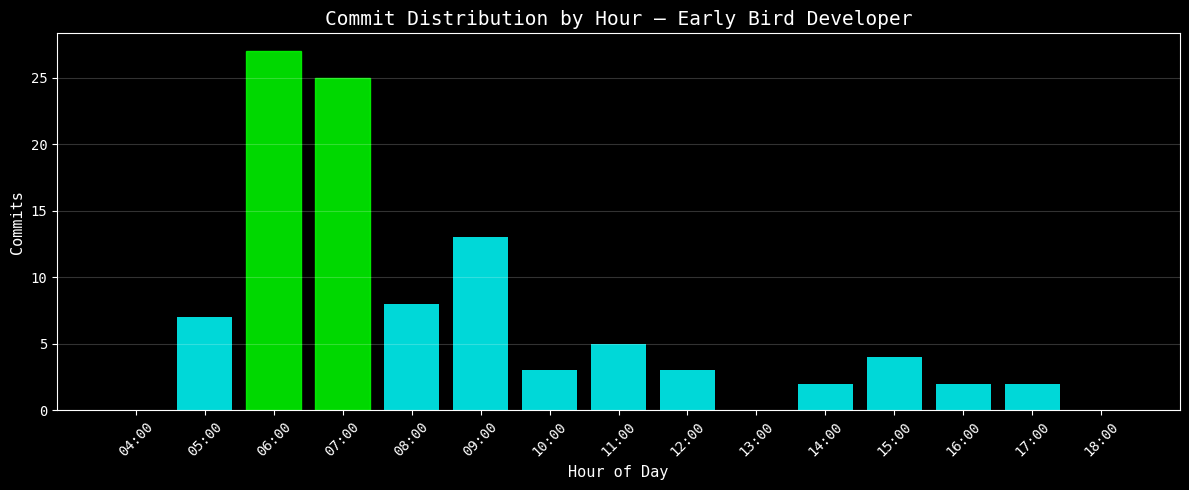

In [6]:
# Commit hour distribution
commit_hours = [
    7,6,7,9,9,11,11,11,11,12,12,12,14,14,15,15,15,15,16,16,17,17,  # Feb 22
    6,6,6,7,7,7,7,8,10,10,  # Feb 23
    5,7,7,7,8,8,8,  # Feb 24
    6,7,  # Feb 25
    5,5,6,7,11,  # Feb 26
    5,5,  # Feb 27
    6,  # Feb 28
    6,6,6,  # Mar 1
    7,7,7,  # Mar 2
    5,  # Mar 3
    5,6,  # Mar 4
    6,6,  # Mar 5
    6,6,  # Mar 6
    8,  # Mar 7
    6,7,  # Mar 8
    6,7,  # Mar 9
    7,  # Mar 10
    6,7,  # Mar 11
    6,  # Mar 12
    7,  # Mar 13
    9,10,  # Mar 14
    6,  # Mar 15
    7,8,  # Mar 16
    6,6,7,7,  # Mar 17
    6,6,6,7,  # Mar 18
    8,9,9,  # Mar 19
    6,7,7,8,9,9,9,9,  # Mar 20
    6,9,9,9,9,  # Mar 21
]

fig, ax = plt.subplots(figsize=(12, 5))
hours_range = range(4, 19)
hour_counts = [commit_hours.count(h) for h in hours_range]

bars = ax.bar(hours_range, hour_counts, color=ZX_CYAN, alpha=0.85)
# Highlight peak hours
for i, h in enumerate(hours_range):
    if h in (6, 7):
        bars[i].set_color(ZX_GREEN)

ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Commits', fontsize=11)
ax.set_title('Commit Distribution by Hour — Early Bird Developer', fontsize=14, color=ZX_WHITE)
ax.set_xticks(list(hours_range))
ax.set_xticklabels([f'{h:02d}:00' for h in hours_range], rotation=45)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

## 7. Feature Delivery Timeline

Each version introduced substantial new features, delivered in rapid succession:

| Version | Date | Days | Key Features |
|---------|------|------|--------------|
| Alfa 0.01 | Feb 22 | Day 1 | Core Pong game + LLM narrator + sound + end screen |
| Alfa 0.02 | Feb 23 | Day 2 | Log system, narration quality, modular refactor |
| Alfa 0.03 | Feb 26 | Day 5 | Interactive questions, emotional AI, ZX Spectrum colors |
| Alfa 0.04 | Feb 27 | Day 6 | MIDI music engine, pause system |
| Alfa 0.05 | Mar 2 | Day 9 | Save system, ZX boot screen, pixel art title, 45 achievements |
| Alfa 0.06 | Mar 7 | Day 14 | Stable Diffusion image generation, stats screen |
| Alfa 0.07 | Mar 20 | Day 27 | Headless testing, mypy strict, 81% coverage, packaging, itch.io release |

**7 versions in 28 days = one release every 4 days on average.**

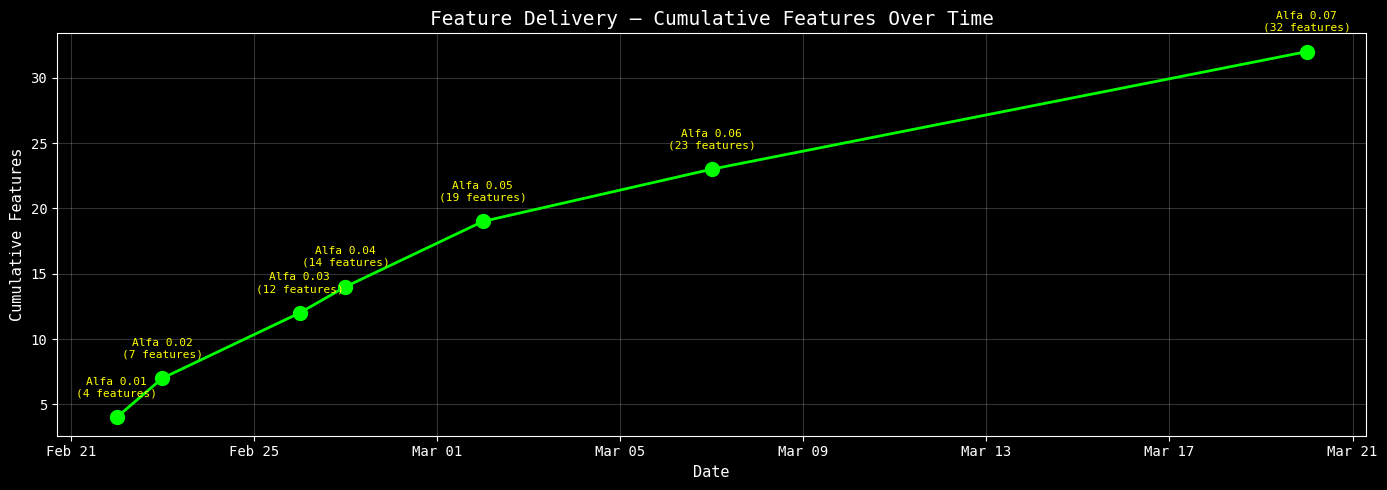

In [7]:
# Feature timeline
version_dates = [
    datetime(2026, 2, 22), datetime(2026, 2, 23), datetime(2026, 2, 26),
    datetime(2026, 2, 27), datetime(2026, 3, 2), datetime(2026, 3, 7),
    datetime(2026, 3, 20),
]
version_names = ['0.01', '0.02', '0.03', '0.04', '0.05', '0.06', '0.07']
cumulative_features = [4, 7, 12, 14, 19, 23, 32]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(version_dates, cumulative_features, 'o-', color=ZX_GREEN, linewidth=2, markersize=10)

for d, name, feat in zip(version_dates, version_names, cumulative_features):
    ax.annotate(f'Alfa {name}\n({feat} features)',
                (d, feat), textcoords='offset points',
                xytext=(0, 15), ha='center', fontsize=8, color=ZX_YELLOW)

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Cumulative Features', fontsize=11)
ax.set_title('Feature Delivery — Cumulative Features Over Time', fontsize=14, color=ZX_WHITE)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 8. Cost & Efficiency Analysis

### Estimated AI Usage

Based on 28 development sessions with Claude Code (Opus model):

| Parameter | Estimate | Basis |
|-----------|----------|-------|
| **Sessions** | ~28 | One per active day |
| **Avg session duration** | ~2.5 hours | Commit timestamp analysis |
| **Total dev hours** | ~70 hours | 28 sessions × 2.5h avg |
| **Tokens per session (est.)** | ~150K–300K | Typical Claude Code session with code generation, search, and iteration |
| **Total tokens (est.)** | ~4M–8M | 28 sessions × 150K-300K |
| **Claude Pro subscription** | $20/month | Fixed cost, 1 month of development |
| **Estimated total AI cost** | ~$20 | Pro subscription covers the usage |

**Note on cost estimation:** Claude Code is included in the Claude Pro ($20/month) and Max ($100/month) subscriptions. The actual token usage is not billed separately. The $20 figure represents the subscription cost during the development period.

### Alternative: Traditional Development Cost

To estimate what this project would cost without AI assistance, we reference industry benchmarks:

**Source:** [2024 Stack Overflow Developer Survey](https://survey.stackoverflow.co/2024/) — median junior-to-mid developer produces ~100-150 lines of production code per day, including testing and documentation.

**Source:** [The Mythical Man-Month (Brooks, 1975)](https://en.wikipedia.org/wiki/The_Mythical_Man-Month) — established benchmark of ~10 lines of *debugged* code per developer per day for complex systems, still widely cited.

**Source:** [GitHub Copilot Impact Study (2022)](https://github.blog/news-insights/research/research-quantifying-github-copilots-impact-on-developer-productivity/) — AI-assisted developers complete tasks 55% faster than unassisted developers.

| Scenario | Lines/Day | Days Needed | Cost (freelancer @$40/h, 6h/day) |
|----------|-----------|-------------|-----------------------------------|
| **With Claude Code (actual)** | ~700 net lines/day | 28 days | $20 (subscription) + developer time |
| **Solo developer (optimistic)** | ~150 lines/day | ~145 days (~5 months) | $34,800 |
| **Solo developer (conservative)** | ~80 lines/day | ~272 days (~9 months) | $65,280 |

The 700 lines/day with Claude includes production code, tests, documentation, CI configuration, and packaging scripts — all delivered with type checking (mypy strict) and 81% test coverage.

### Efficiency Multiplier

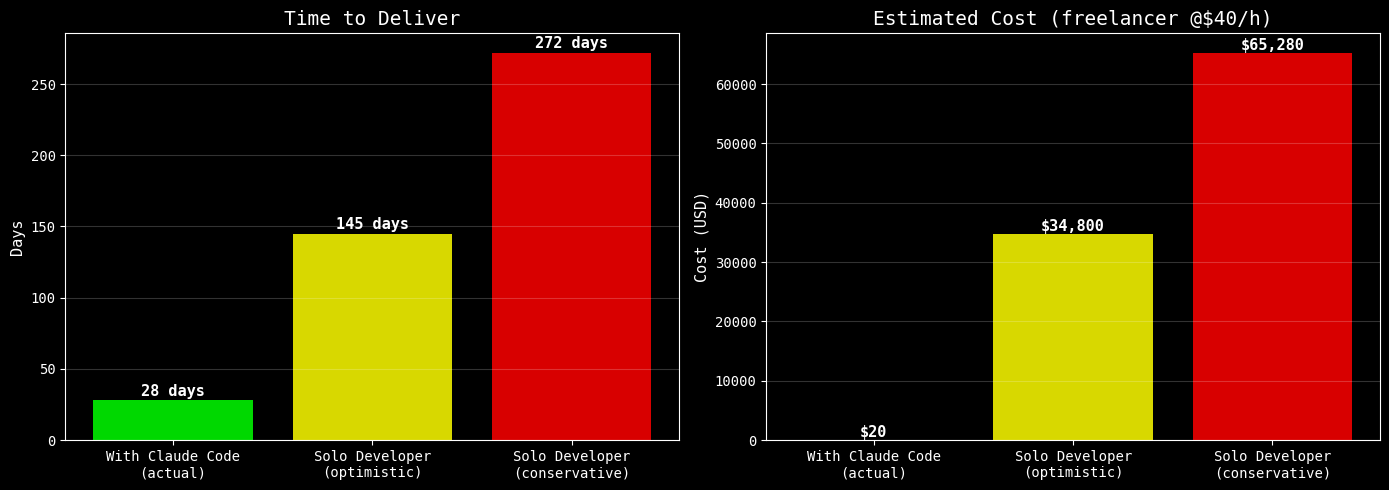

Speed multiplier: 5.2x – 9.7x faster with AI assistance
Cost reduction:   99.9% – 100.0%


In [8]:
# Efficiency comparison
scenarios = ['With Claude Code\n(actual)', 'Solo Developer\n(optimistic)', 'Solo Developer\n(conservative)']
days_needed = [28, 145, 272]
costs = [20, 34800, 65280]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Days comparison
bars1 = ax1.bar(scenarios, days_needed, color=[ZX_GREEN, ZX_YELLOW, ZX_RED], alpha=0.85)
for bar, val in zip(bars1, days_needed):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
             f'{val} days', ha='center', color=ZX_WHITE, fontsize=11, fontweight='bold')
ax1.set_ylabel('Days', fontsize=11)
ax1.set_title('Time to Deliver', fontsize=14, color=ZX_WHITE)
ax1.grid(axis='y', alpha=0.2)

# Cost comparison
bars2 = ax2.bar(scenarios, costs, color=[ZX_GREEN, ZX_YELLOW, ZX_RED], alpha=0.85)
for bar, val in zip(bars2, costs):
    label = f'${val:,}'
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             label, ha='center', color=ZX_WHITE, fontsize=11, fontweight='bold')
ax2.set_ylabel('Cost (USD)', fontsize=11)
ax2.set_title('Estimated Cost (freelancer @$40/h)', fontsize=14, color=ZX_WHITE)
ax2.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

print(f"Speed multiplier: {145/28:.1f}x – {272/28:.1f}x faster with AI assistance")
print(f"Cost reduction:   {(1 - 20/34800)*100:.1f}% – {(1 - 20/65280)*100:.1f}%")

## 9. Quality Metrics

Despite the rapid development pace, the project maintained high code quality standards:

| Quality Metric | Value | Industry Benchmark |
|---------------|-------|-----------|
| **Test coverage** | 81% | 60-80% is considered good ([Martin Fowler](https://martinfowler.com/bliki/TestCoverage.html)) |
| **Test-to-source ratio** | 38% | 20-40% is healthy for production code |
| **Type checking** | mypy --strict | Strictest level, uncommon in personal projects |
| **CI/CD** | 3 workflows (tests, types, builds) | Above average for indie games |
| **Conventional commits** | 55% (57/104) | Demonstrates commit discipline |
| **Documentation** | 6 docs, 2,524 lines | Comprehensive for project size |
| **Versions released** | 7 in 28 days | Rapid iteration cycle |
| **Platforms** | Windows + macOS | Cross-platform from day 1 |

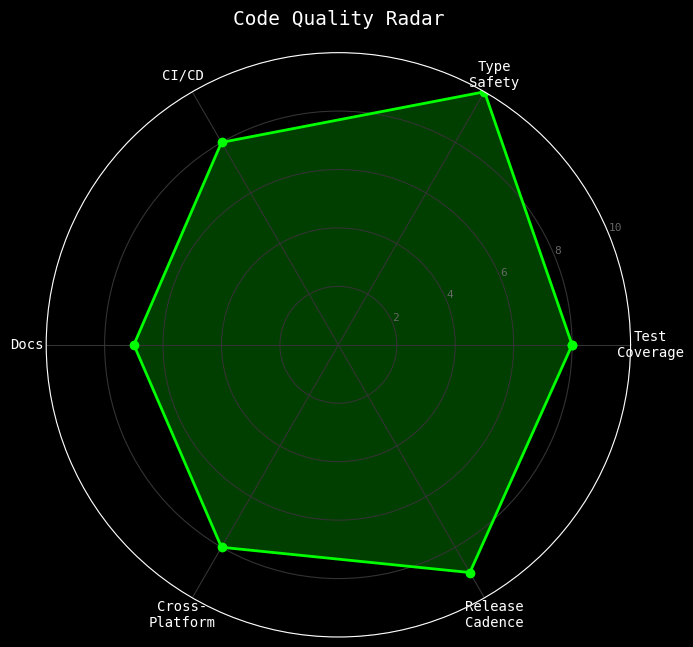

In [9]:
# Quality radar chart
categories_q = ['Test\nCoverage', 'Type\nSafety', 'CI/CD', 'Docs', 'Cross-\nPlatform', 'Release\nCadence']
# Scores 0-10 (subjective but based on metrics above)
scores = [8, 10, 8, 7, 8, 9]
scores += scores[:1]  # close the polygon

angles = np.linspace(0, 2 * np.pi, len(categories_q), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.fill(angles, scores, color=ZX_GREEN, alpha=0.25)
ax.plot(angles, scores, 'o-', color=ZX_GREEN, linewidth=2)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories_q, fontsize=10, color=ZX_WHITE)
ax.set_ylim(0, 10)
ax.set_yticks([2, 4, 6, 8, 10])
ax.set_yticklabels(['2', '4', '6', '8', '10'], fontsize=8, color='#666666')
ax.set_title('Code Quality Radar', fontsize=14, color=ZX_WHITE, pad=20)
ax.grid(color='#333333')
plt.tight_layout()
plt.show()

## 10. Conclusions

### What worked well

- **AI as a force multiplier:** Claude Code enabled delivering a complex, multi-system game (LLM narration, Stable Diffusion, MIDI synthesis, achievements, packaging) in 28 days — a project that would typically take 5-9 months for a solo developer.
- **Quality was not sacrificed for speed:** 81% test coverage, strict type checking, and comprehensive documentation were maintained throughout.
- **Consistent daily progress:** 28 active development days with an average of 3.7 commits per session shows sustained momentum.
- **From zero to published:** The project went from initial commit to a published game on itch.io with installers for two platforms in under a month.

### Key numbers

| Metric | Value |
|--------|-------|
| **Development time** | 28 days (~70 hours) |
| **Total output** | 19,707 lines of Python + 2,524 lines of docs |
| **Productivity** | ~700 net lines/day (5-9x industry average) |
| **AI cost** | ~$20 (Claude Pro subscription) |
| **Equivalent freelancer cost** | $35,000 – $65,000 |
| **Speed multiplier** | 5x – 10x faster than solo development |

---

*Report generated on March 21, 2026. Data extracted from git history of [jgf-games/pong-ia](https://jgf-games.itch.io/pong-ia).*